------
-----

<h2 style='color:red;background-color:white;text-align:center;'><b>Machine Learning-Based Late Delivery Risk Prediction in Global Supply Chain Operations<b></h1>

-------------------
------------------

# Introduction

 Late delivery of shipments is one of the major challenges in global supply chain operations, affecting customer satisfaction, operational efficiency, and business profitability. Delayed deliveries can lead to increased logistics costs, inefficient resource allocation, and disruptions across the supply chain network. Leveraging machine learning techniques enables organizations to proactively identify delivery risks and make informed operational decisions before delays occur.

 This project aims to develop a machine learning-based framework for predicting late delivery risks using logistics and order-related data. By analyzing shipment characteristics, customer information, regional factors, and operational variables, the proposed system seeks to classify delivery risks and provide actionable business insights for improving supply chain performance.

## Business Problem


Global supply chain operations involve complex interactions among shipping schedules, customer demands, transportation networks, and regional logistics processes. Unexpected delivery delays can significantly impact customer satisfaction, increase operational costs, and reduce supply chain efficiency. Organizations often face challenges in identifying high-risk orders before shipment delays occur, limiting their ability to implement proactive mitigation strategies.

The absence of predictive risk assessment mechanisms makes it difficult to prioritize operational interventions and allocate resources effectively. Consequently, there is a growing need for intelligent systems capable of forecasting late delivery risks and supporting data-driven decision-making within logistics operations.

## Project Objectives



The primary objective of this project is to develop a machine learning-based predictive framework for identifying late delivery risks in global supply chain operations. The proposed system aims to support proactive decision-making by forecasting shipment delays and providing interpretable risk assessments.

The specific objectives of this project are to:

- Predict the likelihood of late deliveries using machine learning techniques.
- Classify orders into appropriate delivery risk categories based on their predicted risk scores.
- Identify the key operational factors contributing to shipment delays.
- Perform comprehensive exploratory data analysis to uncover meaningful logistics and delivery patterns.
- Develop an explainable and reliable predictive model for late delivery risk assessment.
- Provide actionable business insights to improve supply chain efficiency and operational planning.
- Design an interactive Streamlit dashboard for delivery risk monitoring and operational decision support.

## Dataset Overview



This project utilizes a large-scale logistics dataset containing shipment, customer, product, sales, and delivery-related information collected from global supply chain operations. The dataset encompasses multiple operational attributes that influence delivery performance, including shipping schedules, regional logistics factors, customer characteristics, and order-level information.

The available features provide valuable insights for analyzing delivery patterns and identifying potential risk factors associated with shipment delays. By leveraging these diverse operational variables, the dataset supports the development of predictive models capable of estimating late delivery risks and generating actionable business intelligence for supply chain management.

## Problem Type



This project addresses a supervised machine learning problem focused on predicting late delivery risks within global supply chain operations. The objective is to utilize historical logistics and shipment-related information to estimate the likelihood of delivery delays before they occur.

From a machine learning perspective, the problem is formulated as a binary classification task, where each order is classified based on its delivery risk status. In addition to predicting delivery outcomes, the proposed framework provides probabilistic risk estimates and interpretable insights to support operational decision-making. The integration of predictive analytics with business intelligence enables organizations to proactively identify high-risk shipments and implement timely mitigation strategies.



# DATA UNDERSTANDING



### Import Libraries

In [1]:
# ============================================================
# Data Manipulation
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# Data Visualization
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


# ============================================================
# Machine Learning Utilities
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


# ============================================================
# Machine Learning Models
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier


# ============================================================
# Class Imbalance Handling
# ============================================================

from imblearn.over_sampling import SMOTE


# ============================================================
# Model Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# Model Persistence
# ============================================================

import joblib
import pickle
# ============================================================
# System Utilities
# ============================================================

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ===================================================
# CREATE PROJECT FOLDERS
# ===================================================

import os 

folders = [
    "graphs",
    "exports",
    "models",
    "reports"
]

for folder in folders:
    os.makedirs(
        folder,
        exist_ok=True
    )

print("Project folders created successfully.")

Project folders created successfully.


In [3]:
# ============================================================
# Project Path Management
# ============================================================

from pathlib import Path


# ============================================================
# Project Root Directory
# ============================================================

PROJECT_ROOT = Path.cwd()


# ============================================================
# Dataset Path
# ============================================================

DATA_PATH = PROJECT_ROOT / "data" / "APL_Logistics.csv"


# ============================================================
# Folder Paths
# ============================================================

GRAPHS_PATH = PROJECT_ROOT / "graphs"
MODELS_PATH = PROJECT_ROOT / "models"
EXPORTS_PATH = PROJECT_ROOT / "exports"
REPORTS_PATH = PROJECT_ROOT / "reports"

### Load Dataset

In [4]:
# ============================================================
# Verify Dataset Availability
# ============================================================

print(f"Dataset Exists : {DATA_PATH.exists()}")
print(f"Dataset Path   : {DATA_PATH}")

Dataset Exists : True
Dataset Path   : c:\Desktop\Supply-Chain-Late-Delivery-Risk-Prediction\data\APL_Logistics.csv


In [5]:
import chardet

with open(DATA_PATH,"rb") as file:
    result = chardet.detect(file.read())

print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.04431193330766844, 'language': 'en', 'mime_type': 'text/plain'}


In [6]:
# ============================================================
# Load Dataset
# ============================================================


df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")

# ============================================================
# Dataset Successfully Loaded
# ============================================================

print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


### Dataset Shape

In [7]:
# Dataset Shape 

rows, columns = df.shape

# display dataset dimensions

print(f"Number of Rows: {rows:,}")
print(f"Number of Columns:{columns}")

Number of Rows: 180,519
Number of Columns:40


In [8]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


### Preview Dataset

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Fname                 180519 non-null  str    
 12  Customer Id                    180519 non

In [10]:
df.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
180514,TRANSFER,6,4,-107.96,161.87,Late delivery,1,76,Women's Clothing,Caguas,...,1,215.82,161.87,-107.96,Southeast Asia,Java Occidental,PROCESSING,Summer dresses,215.82,Standard Class
180515,DEBIT,2,4,-126.56,172.66,Advance shipping,0,76,Women's Clothing,Plainfield,...,1,215.82,172.66,-126.56,Southeast Asia,Java Occidental,COMPLETE,Summer dresses,215.82,Standard Class
180516,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,...,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,Smart watch,327.75,Standard Class
180517,PAYMENT,4,4,1.53,10.91,Shipping on time,0,74,Toys,Berwyn,...,1,11.54,10.91,1.53,Southeast Asia,Java Occidental,PENDING_PAYMENT,Toys,11.54,Standard Class
180518,CASH,1,0,9.79,34.98,Late delivery,1,75,Video Games,Miami,...,1,39.75,34.98,9.79,Oceania,Queensland,CLOSED,Fighting video games,39.75,Same Day


### Column Names

In [11]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname',
       'Customer Segment', 'Customer State', 'Customer Street',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Name', 'Product Price', 'Shipping Mode'],
      dtype='str')

### Statistical Summary

In [12]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107607,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,6691.379495,20.664741,0.101668,141.232547,0.120647,2.127638,203.772092,183.107607,21.974989,141.232547
std,1.623722,1.374449,104.433526,120.043668,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,4162.918106,21.800901,0.070415,139.732489,0.466796,1.453451,132.273075,120.043668,104.433526,139.732489
min,0.000000,0.000000,-4274.980000,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,0.000000,0.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.980000,9.990000
25%,2.000000,2.000000,7.000000,104.380000,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,3258.500000,5.400000,0.040000,50.000000,0.080000,1.000000,119.980000,104.380000,7.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990000,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,6457.000000,14.000000,0.100000,59.990000,0.270000,1.000000,199.920000,163.990000,31.520000,59.990000
75%,5.000000,4.000000,64.800000,247.400000,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,9779.000000,29.990000,0.160000,199.990000,0.360000,3.000000,299.950000,247.400000,64.800000,199.990000
max,6.000000,4.000000,911.800000,1939.990000,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,20757.000000,500.000000,0.250000,1999.990000,0.500000,5.000000,1999.990000,1939.990000,911.800000,1999.990000


In [13]:
# ============================================================
# Statistical Summary for Numerical Columns
# ============================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.980000,7.000000,31.520000,64.800000,911.800000
Sales per customer,180519.0,183.107607,120.043668,7.490000,104.380000,163.990000,247.400000,1939.990000
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


### Missing Value Analysis

In [14]:
# ============================================================
# Missing Values Count
# ============================================================

df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Id                      0
Customer Lname                   8
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 3
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product P

In [15]:
# ============================================================
# Columns Containing Missing Values
# ============================================================

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Customer Lname      8
Customer Zipcode    3
dtype: int64

### Duplicate Value Analysis

In [16]:
# ============================================================
# Duplicate Records
# ============================================================

print(f"Duplicate Records : {df.duplicated().sum()}")

Duplicate Records : 0


### Target Variable Analysis

In [17]:
# Target Variable Distribution

df["Late_delivery_risk"].value_counts()



Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

#  DATA QUALITY ASSESSMENT

Assessing data quality is an essential prerequisite for building reliable machine learning models. The presence of missing values, duplicate records, inconsistent data types, and imbalanced target distributions can significantly influence model performance and business interpretations.

This section focuses on evaluating the completeness, consistency, and reliability of the logistics dataset before proceeding to exploratory data analysis and predictive modelling.

In [18]:
# Missing Value Percentage 

missing_percentage = (
    (df.isnull().sum()/len(df))*100
).round(2)

missing_percentage[missing_percentage>0].sort_values(
      ascending=False
   )

Series([], dtype: float64)

In [19]:
# ============================================================
# Unique Values Summary
# ============================================================

unique_values = pd.DataFrame({

    "Unique Values":df.nunique()

})

unique_values.sort_values(
    by="Unique Values",
    ascending=False
)

,Unique Values
Benefit per order,21998
Order Profit Per Order,21998
Customer Id,20652
Order Customer Id,20652
Latitude,11250
Customer Street,7458
Longitude,4487
Order City,3597
Sales per customer,2927
Order Item Total,2927


In [20]:
# ============================================================
# Target Variable Percentage Distribution
# ============================================================

(
df["Late_delivery_risk"]
.value_counts(normalize=True)*100
).round(2)

Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64

### Class Imbalance Analysis

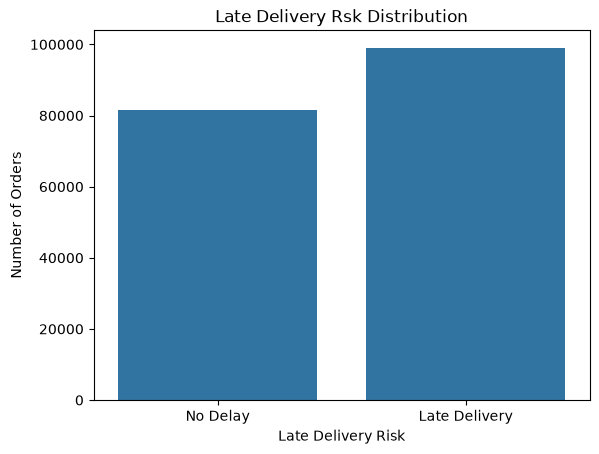

In [21]:
# Visualize Target Variable Distribution

plt.Figure(figsize=(8,5))

sns.countplot(
    data = df,
    x="Late_delivery_risk"
)

plt.title("Late Delivery Rsk Distribution")
plt.xlabel("Late Delivery Risk")
plt.xticks(
     ticks=[0,1],
     labels=["No Delay","Late Delivery"]
)
plt.ylabel("Number of Orders")

plt.savefig(
    GRAPHS_PATH / "late_delivery_risk_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()


### Interpretation:

The dataset contains a substantial number of both delayed and non-delayed orders, with late deliveries occurring slightly more frequently. The target variable is reasonably balanced for predictive modelling.

#  EXPLORATORY DATA ANALYSIS (EDA)

Exploratory Data Analysis plays a critical role in understanding shipment behaviour, delivery performance, customer characteristics, and operational patterns within the supply chain network. This section focuses on identifying meaningful trends, relationships, and risk indicators associated with late deliveries.

The analysis emphasizes business-relevant variables that contribute to delivery risk prediction and operational decision-making. Visualizations and statistical summaries are used to uncover patterns that support feature engineering and machine learning model development.

### Delivery Performance Analysis

Delivery performance is one of the most important indicators of supply chain efficiency. Understanding the relationship between scheduled shipping durations and actual delivery times provides valuable insights into operational effectiveness and potential delivery risks.

This analysis focuses on shipment timelines, delivery status patterns, and operational delays that may contribute to late delivery occurrences across the logistics network.

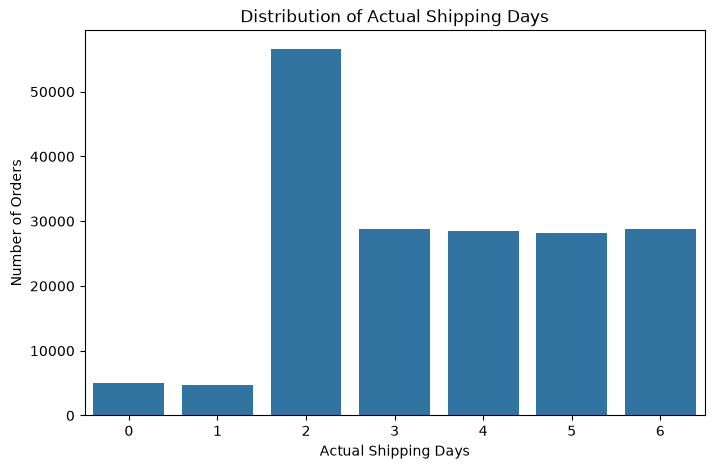

In [22]:
# ============================================================
# Distribution of Actual Shipping Days
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Days for shipping (real)"
)

plt.title("Distribution of Actual Shipping Days")
plt.xlabel("Actual Shipping Days")
plt.ylabel("Number of Orders")

plt.savefig(
    GRAPHS_PATH / "actual_shipping_days_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Interpretation:
Most orders are delivered within 2 days, while the remaining orders are distributed across 3 to 6 shipping days. Same-day and 1-day deliveries are comparatively less common

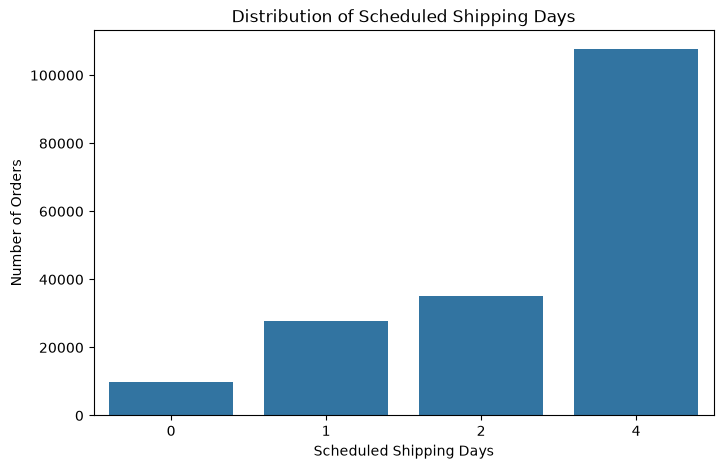

In [23]:
# ============================================================
# Distribution of Scheduled Shipping Days
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Days for shipment (scheduled)"
)

plt.title("Distribution of Scheduled Shipping Days")
plt.xlabel("Scheduled Shipping Days")
plt.ylabel("Number of Orders")

plt.savefig(
    GRAPHS_PATH / "scheduled_shipping_days_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Interpretation:
A large proportion of orders are scheduled for 4-day deliveries, followed by shorter delivery commitments. This indicates that longer planned delivery windows are more commonly utilized.

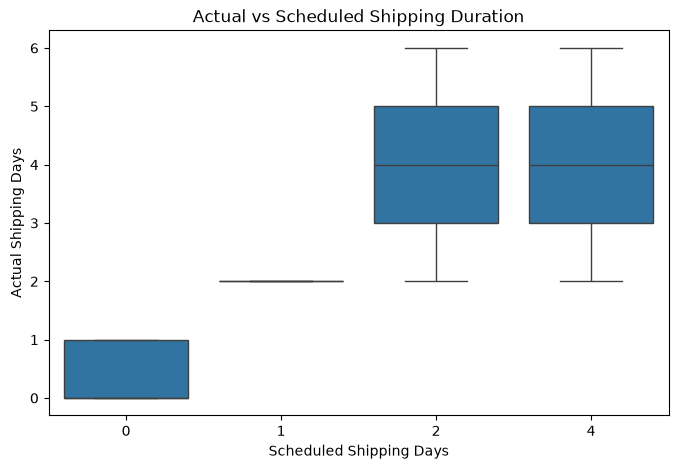

In [24]:
# ============================================================
# Actual vs Scheduled Shipping Days
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Days for shipment (scheduled)",
    y="Days for shipping (real)"
)

plt.title( "Actual vs Scheduled Shipping Duration")

plt.xlabel( "Scheduled Shipping Days")

plt.ylabel(  "Actual Shipping Days")
plt.savefig(
    GRAPHS_PATH / "actual_vs_scheduled_shipping_duratio.png",
    bbox_inches="tight",
    dpi=300
)


plt.show()

### Interpretation:
Actual shipping durations vary across scheduled delivery timelines, indicating that operational performance does not always align perfectly with planned schedules. Some delivery windows exhibit greater variability than others.

In [25]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname',
       'Customer Segment', 'Customer State', 'Customer Street',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Name', 'Product Price', 'Shipping Mode'],
      dtype='str')

### Shipping Mode Distribution

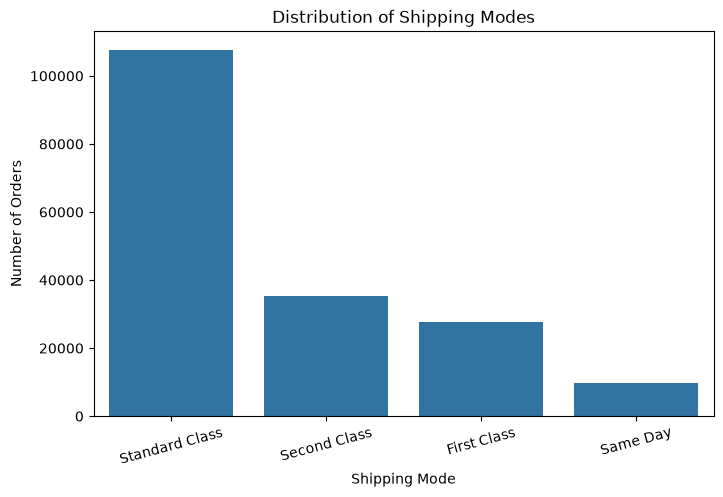

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Shipping Mode",
    order=df["Shipping Mode"].value_counts().index
)

plt.title("Distribution of Shipping Modes")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")
plt.xticks(rotation=15)

plt.savefig(
    GRAPHS_PATH / "shipping_modes_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()


### Interpretation:
Standard Class is the most frequently used shipping mode, followed by Second Class and First Class, while Same Day deliveries account for the smallest share of orders.

### Customer Segment Distribution

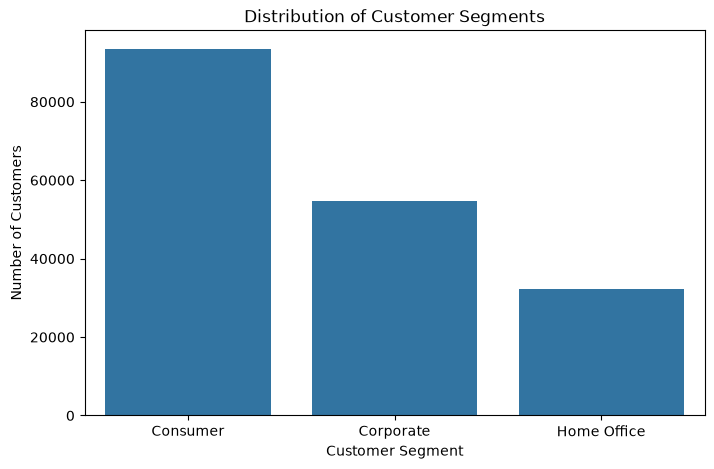

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Customer Segment",
    order=df["Customer Segment"].value_counts().index
)

plt.title("Distribution of Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.savefig(
    GRAPHS_PATH / "customer_segment_distribution.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Interpretation:
 Consumer customers contribute the highest number of orders, followed by Corporate and Home Office segments.

### Top 10 Product Categories

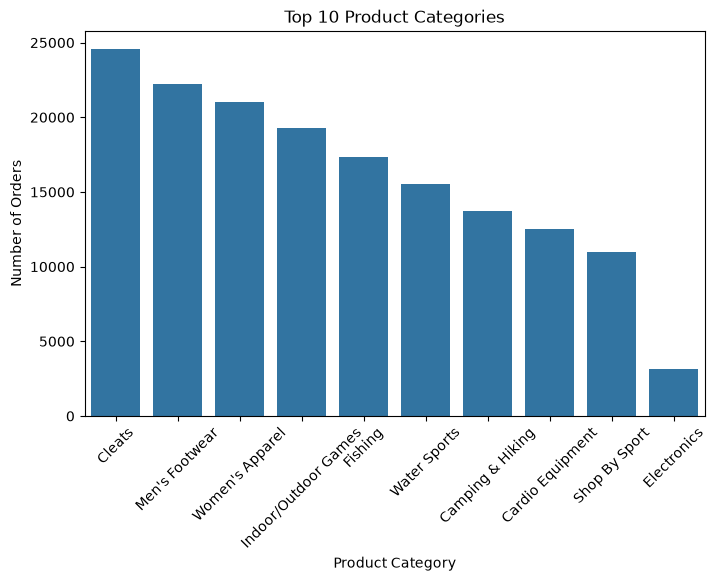

In [28]:
plt.figure(figsize=(8,5))

top_categories=(
    df["Category Name"].value_counts().head(10)
)
sns.barplot(
    x= top_categories.index,
    y = top_categories.values
)
plt.title("Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation = 45)

plt.savefig(
    GRAPHS_PATH / "top_10_product_categories.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Interpretation:
 Cleats, Men's Footwear, and Women's Apparel are among the highest-selling categories, whereas Electronics contributes comparatively fewer orders within the top ten categories.

### Regional Analysis

identifying which regions generate the highest number of orders.

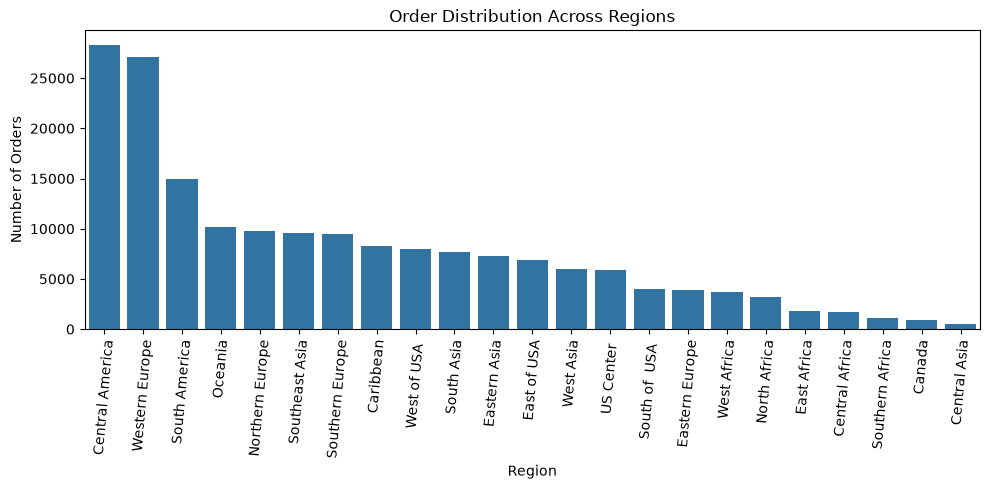

In [29]:
# ==========================================================
# Order Distribution Across Regions
# ==========================================================

plt.figure(figsize=(10,5))

region_orders = (
    df["Order Region"]
    .value_counts()
)

sns.barplot(
    x=region_orders.index,
    y=region_orders.values
)

plt.title("Order Distribution Across Regions")
plt.xlabel("Region")
plt.ylabel("Number of Orders")

plt.xticks(rotation=85)
plt.tight_layout()
plt.savefig(
    GRAPHS_PATH / "order_distribution_across_regions.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Interpretation:
 Central America and Western Europe contribute the highest number of orders, while regions such as Canada and Central Asia account for relatively fewer orders.

### Market Distribution

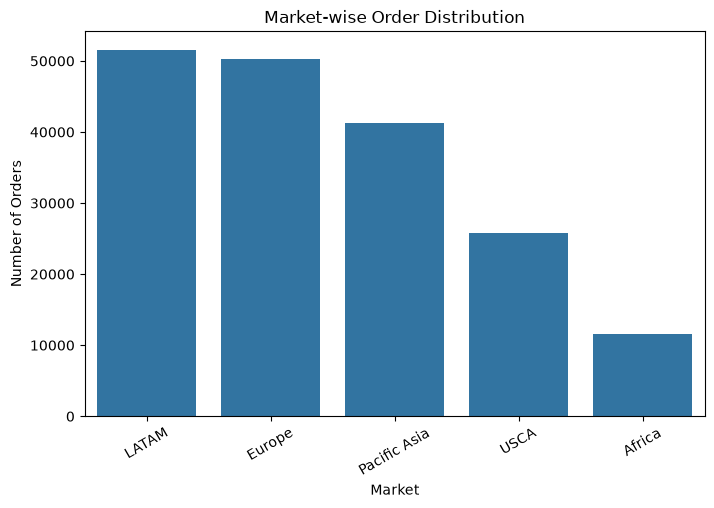

In [30]:
# ==========================================================
# Market-wise Order Distribution
# ==========================================================

plt.figure(figsize=(8,5))

market_orders = (
    df["Market"]
    .value_counts()
)

sns.barplot(
    x=market_orders.index,
    y=market_orders.values
)

plt.title("Market-wise Order Distribution")
plt.xlabel("Market")
plt.ylabel("Number of Orders")

plt.xticks(rotation=30)
plt.savefig(
    GRAPHS_PATH / "market-wise_order_distribution.png",
    bbox_inches="tight",
    dpi=300
)


plt.show()

### Interpretation: 
LATAM and Europe are the dominant markets in terms of order volume, followed by Pacific Asia. Africa contributes the fewest orders among the major markets.

### Sales Analysis

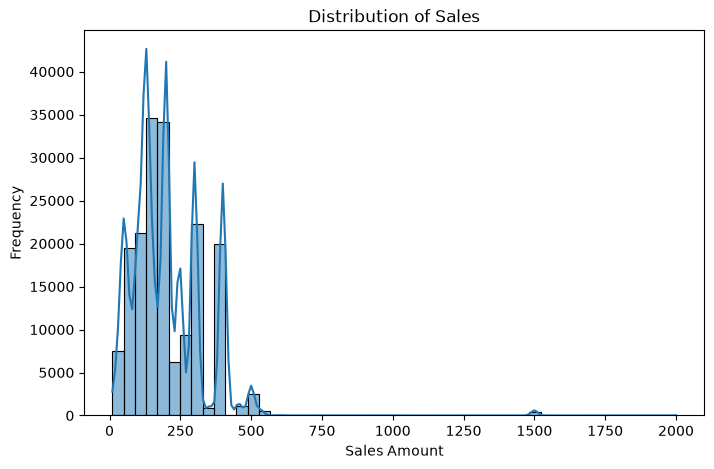

In [31]:
# ==========================================================
# Sales Distribution
# ==========================================================


plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Sales",
    bins=50,
    kde=True
)
plt.title("Distribution of Sales")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.savefig(
    GRAPHS_PATH / "sales_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Interpretation:
 Most orders are concentrated in the lower-to-mid sales range, while a small number of transactions contribute exceptionally high sales values.

### Sales by Customer Segment

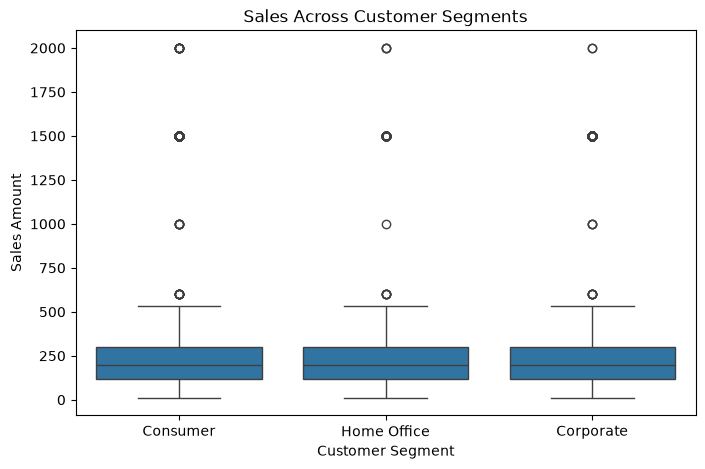

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Customer Segment",
    y="Sales"
)

plt.title("Sales Across Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Sales Amount")
plt.savefig(
    GRAPHS_PATH / "sales_across_customer_segments.png",
    bbox_inches="tight",
    dpi=300
)


plt.show()

### Interpretation: 
Consumer, Corporate, and Home Office segments exhibit relatively similar sales distributions, with each segment containing several high-value purchases.

### Top 10 Products by Sales

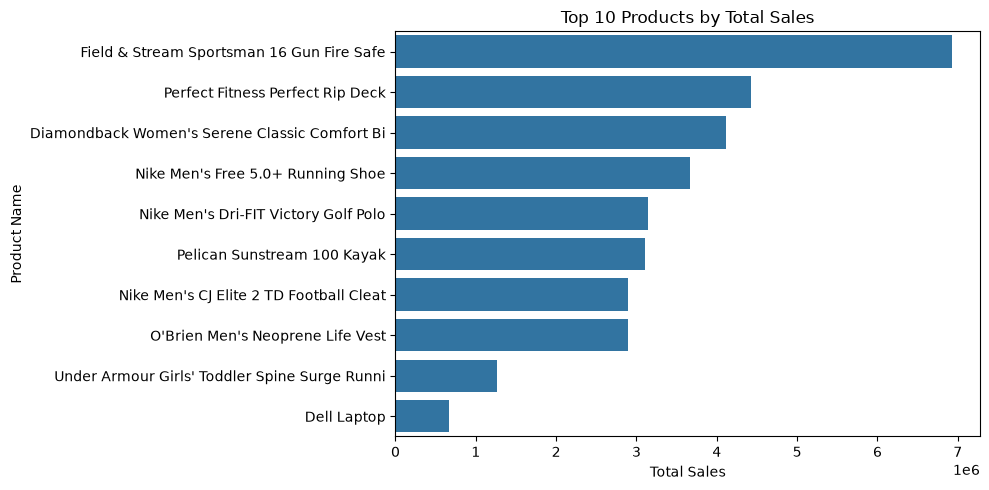

In [33]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.tight_layout()
plt.savefig(
    GRAPHS_PATH / "top_10_products_by_total_sales.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Interpretation: 
A small group of products generates a substantial share of total sales, led by the Field & Stream Sportsman 16 Gun Fire Safe.

### ***Late Delivery Risk Analysis (Target Variable Analysis)***

These visualizations are particularly important because Late_delivery_risk is our target variable.

### Late Delivery Risk Across Shipping Modes

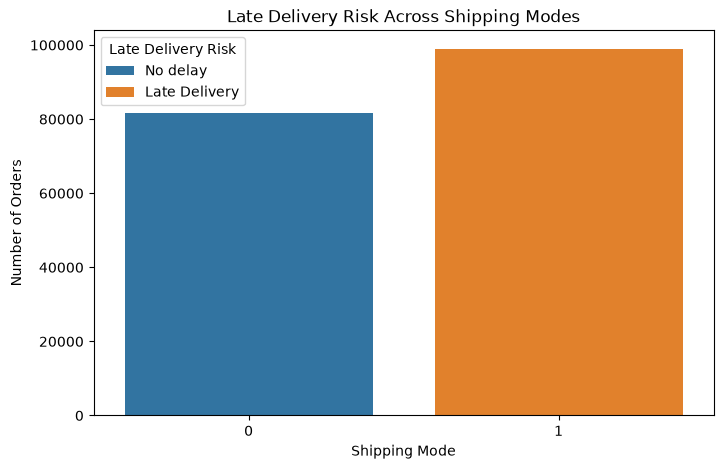

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Late_delivery_risk",
    hue="Late_delivery_risk"
)
plt.title("Late Delivery Risk Across Shipping Modes")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")
plt.legend(
    title="Late Delivery Risk",
    labels=["No delay","Late Delivery"]
)
plt.savefig(
    GRAPHS_PATH / "late_delivery_risk_across_shipping_modes.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Interpretation: 
Late deliveries exceed on-time deliveries, indicating that delivery delays are a persistent operational challenge across shipping methods.

### Late Delivery Risk Across Customer Segments

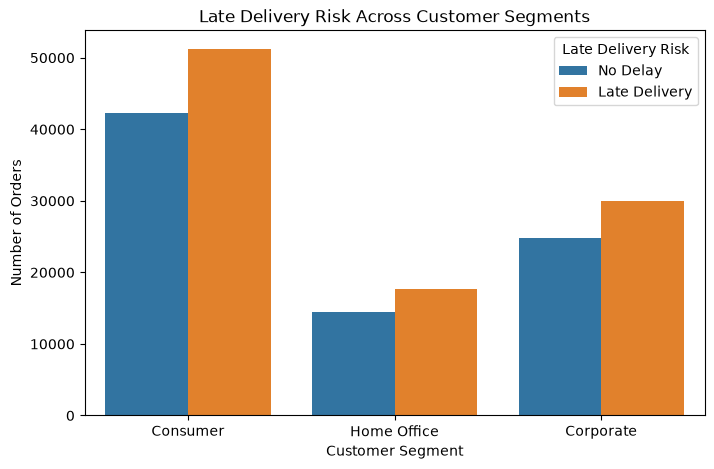

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Customer Segment",
    hue="Late_delivery_risk"
)

plt.title("Late Delivery Risk Across Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Orders")

plt.legend(
    title="Late Delivery Risk",
    labels=["No Delay","Late Delivery"]
)
plt.savefig(
    GRAPHS_PATH / "late_delivery_risk_across_customer_segments.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Interpretation: 
Consumer customers account for the largest number of late deliveries, followed by Corporate and Home Office segments.

### Late Delivery Risk Across Markets

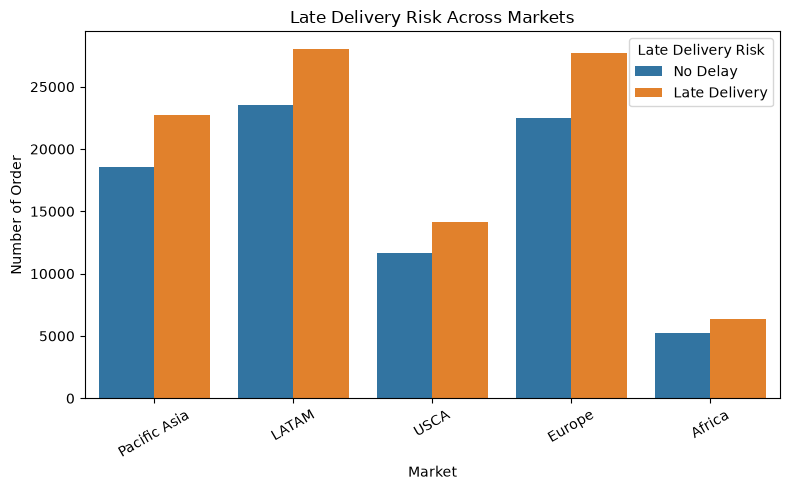

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Market",
    hue="Late_delivery_risk"
)

plt.title("Late Delivery Risk Across Markets")
plt.xlabel("Market")
plt.ylabel("Number of Order")

plt.xticks(rotation=30)

plt.legend(
    title="Late Delivery Risk",
    labels=["No Delay","Late Delivery"]
)
plt.tight_layout()
plt.savefig(
    GRAPHS_PATH / "late_delivery_risk_across_markets.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Interpretation: 
LATAM and Europe record the highest volumes of late deliveries, while Africa has the lowest order volume and comparatively fewer delays.

### Correlation Analysis (Feature Relationships)

let's identify how numerical variables relate to one another.

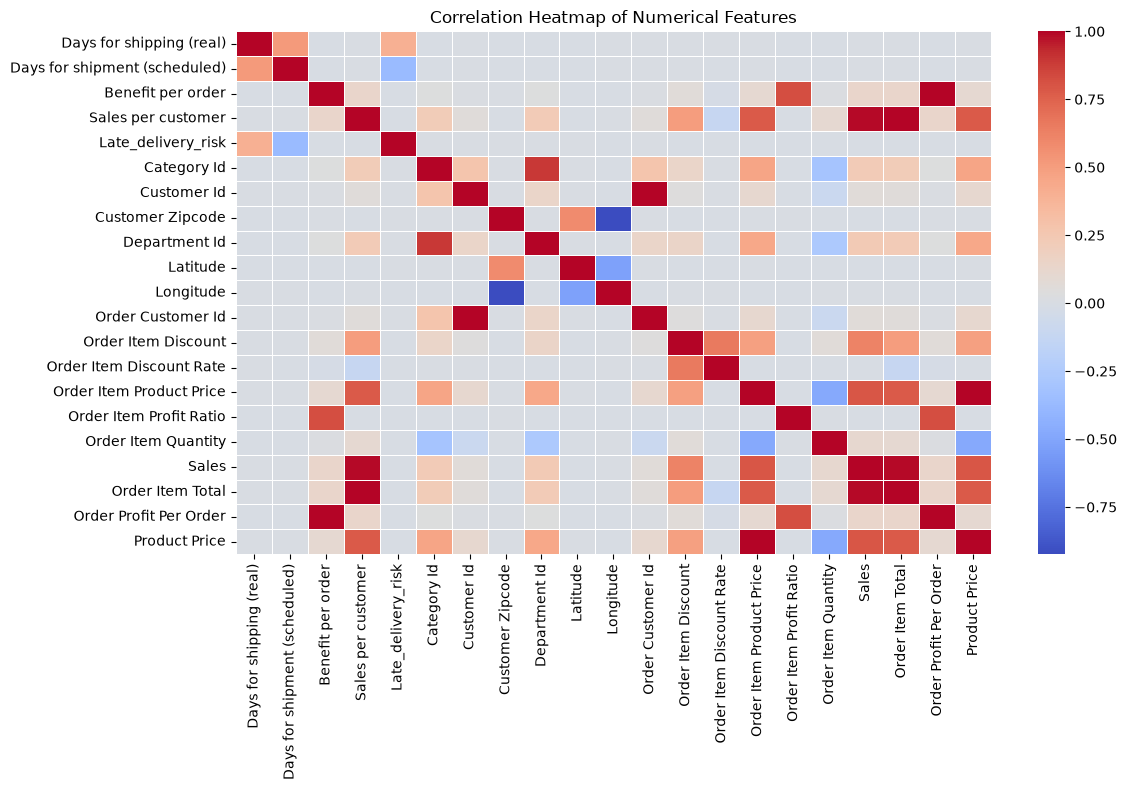

In [37]:
# ==========================================================
# Correlation Analysis of Numerical Features
# ==========================================================

plt.figure(figsize=(12,8))

numeric_columns = df.select_dtypes(
    include=["int64","float64"]
).columns

correlation_matrix = df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False,
    linewidth=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig(
    GRAPHS_PATH / "numerical_features_correlation_heatmap.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Interpretation: 
Most numerical features have weak correlations with one another. However, sales-related variables show strong positive relationships, while Days for Shipping (real) has the strongest positive relationship with Late_delivery_risk.

### Top Correlated Features with Late Delivery Risk

In [38]:
late_delivery_corr = (
    correlation_matrix["Late_delivery_risk"]
    .sort_values(ascending=False)
)
print(late_delivery_corr)

Late_delivery_risk               1.000000
Days for shipping (real)         0.401415
Customer Zipcode                 0.003148
Category Id                      0.001752
Customer Id                      0.001484
Order Customer Id                0.001484
Department Id                    0.001077
Latitude                         0.000679
Order Item Discount Rate         0.000404
Order Item Quantity             -0.000139
Order Item Discount             -0.000750
Longitude                       -0.001915
Order Item Product Price        -0.002175
Product Price                   -0.002175
Order Item Profit Ratio         -0.002316
Sales                           -0.003564
Order Profit Per Order          -0.003727
Benefit per order               -0.003727
Sales per customer              -0.003791
Order Item Total                -0.003791
Days for shipment (scheduled)   -0.369352
Name: Late_delivery_risk, dtype: float64


### Visualize Top Correlations

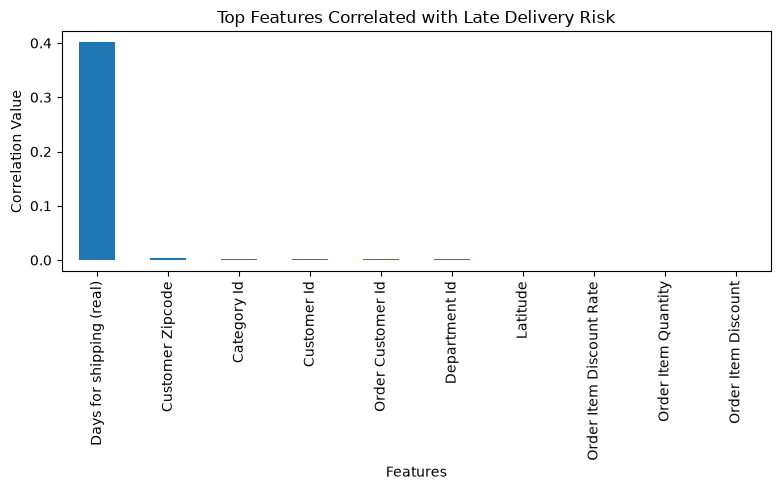

In [39]:
# ==========================================================
# Top Correlated Features
# ==========================================================

plt.figure(figsize=(8,5))

(
    late_delivery_corr[1:11]
    .plot(kind="bar")
)

plt.title(
    "Top Features Correlated with Late Delivery Risk"
)

plt.xlabel("Features")
plt.ylabel("Correlation Value")

plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(
    GRAPHS_PATH / "top_features_correlated_with_late_delivery_risk.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Interpretation:
 Days for Shipping (real) shows the highest positive correlation with late delivery risk, whereas the remaining variables have very weak relationships with delivery delays.


#  DATA PREPROCESSING



## Selecting Features for Machine Learning

The target variable for this project is:

> - Late Delivery Risk (1 = Late Delivery, 0 = No Delay)

The following steps will be performed:

1. Selecting relevant predictor variables.
2. Removing unnecessary columns.
3. Encoding categorical variables.
4. Creating feature and target datasets.
5. Performing train-test splitting.
6. Scaling numerical features.
7. Checking class distribution.
8. Preparing the final dataset for model training.


In [40]:
# ======================================================
# CHECK ALL AVAILABLE COLUMNS
# ======================================================

print("\n Total Columns :",len(df.columns))
print("\n Dataset Columns:\n")

for column in df.columns:
    print(column)


 Total Columns : 40

 Dataset Columns:

Type
Days for shipping (real)
Days for shipment (scheduled)
Benefit per order
Sales per customer
Delivery Status
Late_delivery_risk
Category Id
Category Name
Customer City
Customer Country
Customer Fname
Customer Id
Customer Lname
Customer Segment
Customer State
Customer Street
Customer Zipcode
Department Id
Department Name
Latitude
Longitude
Market
Order City
Order Country
Order Customer Id
Order Item Discount
Order Item Discount Rate
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Order Region
Order State
Order Status
Product Name
Product Price
Shipping Mode


In [41]:
# ======================================================
# CHECK TARGET VARIABLE
# ======================================================

print("\n Late Delivery Risk Distribution \n")
print(df["Late_delivery_risk"].value_counts())
print("\n")
print(df["Late_delivery_risk"].value_counts(normalize=True)*100)


 Late Delivery Risk Distribution 

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64


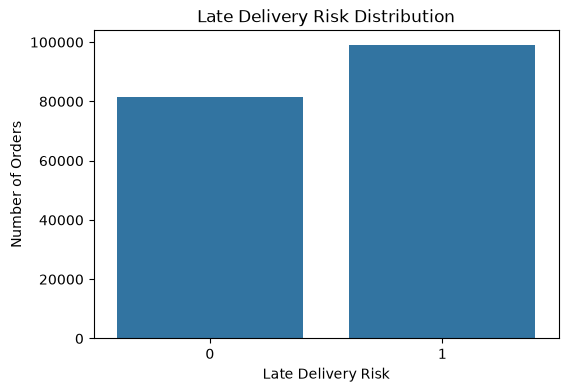

In [42]:
# ======================================================
# VISUALIZE TARGET VARIABLE
# ======================================================

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Late_delivery_risk"
)

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Orders")
plt.savefig(
    GRAPHS_PATH / "late_delivery_risk_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Interpretation:

This visualization shows the distribution of delayed and non-delayed orders in the dataset. It helps determine whether the target variable is balanced or whether additional techniques such as class balancing may be required during model development.


In [43]:
# ======================================================
# CHECK DATA TYPES
# ======================================================

print(df.dtypes)

Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market                               str
Order City                           str
Order Country   

In [44]:
# ======================================================
# NUMERICAL AND CATEGORICAL FEATURES
# ======================================================

numerical_columns = df.select_dtypes(
    include=["int64","float64"]
).columns

categorical_columns = df.select_dtypes(
    include= ["object"]
).columns

print("\n Number of Numerical Features :",len(numerical_columns))

print("\n Number of Categorical Features :",len(categorical_columns))


 Number of Numerical Features : 21

 Number of Categorical Features : 19


In [45]:
# ======================================================
# DISPLAY FEATURE LIST
# ======================================================

print("\n Numerical Features\n")

for column in numerical_columns:
    print(column)

print("\n Categorical Features \n")

for column in categorical_columns:
    print(column)


 Numerical Features

Days for shipping (real)
Days for shipment (scheduled)
Benefit per order
Sales per customer
Late_delivery_risk
Category Id
Customer Id
Customer Zipcode
Department Id
Latitude
Longitude
Order Customer Id
Order Item Discount
Order Item Discount Rate
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Product Price

 Categorical Features 

Type
Delivery Status
Category Name
Customer City
Customer Country
Customer Fname
Customer Lname
Customer Segment
Customer State
Customer Street
Department Name
Market
Order City
Order Country
Order Region
Order State
Order Status
Product Name
Shipping Mode


### Interpretation:

Identifying numerical and categorical variables is essential before preprocessing. Numerical variables may require scaling, whereas categorical variables will require encoding techniques before they can be used by machine learning algorithms.


#   FEATURE SELECTION AND DATA PREPARATION

In [46]:
# ======================================================
# CHECK FOR MISSING VALUES
# ======================================================


missing_values = df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
]

print("\n Columns Having Missing Values \n")

print(missing_values)

# ======================================================
# TOTAL MISSING VALUES
# ======================================================

print("\n Total Missing Values :", df.isnull().sum().sum())


 Columns Having Missing Values 

Customer Lname      8
Customer Zipcode    3
dtype: int64

 Total Missing Values : 11


The dataset is examined for missing values before model development. Identifying incomplete observations is important because machine learning algorithms require clean and consistent data for reliable predictions.


In [47]:
# ======================================================
# CHECK DUPLICATE RECORDS
# ======================================================

duplicates = df.duplicated().sum()
print("\n Total Number of Duplicate Records :", duplicates)


 Total Number of Duplicate Records : 0


Duplicate records may negatively affect model performance by introducing bias. Therefore, checking for duplicate observations is an essential preprocessing step before feature engineering and model training.


In [48]:
# ======================================================
# DEFINE TARGET VARIABLE
# ======================================================

target = "Late_delivery_risk"

print("\n Target Variable :",target)


 Target Variable : Late_delivery_risk


In [49]:
# ======================================================
# REMOVE TARGET VARIABLE
# ======================================================

X = df.drop(columns=[target])

y = df[target]

print("\n Feature Shape :", X.shape)

print("\n Target Shape :",y.shape)


 Feature Shape : (180519, 39)

 Target Shape : (180519,)


In [50]:
# ======================================================
# CHECK TARGET CLASSES
# ======================================================

print(y.value_counts())

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


## FEATURE SELECTION

This section focuses on selecting useful predictor variables for machine learning models.

In [51]:
# ======================================================
# DISPLAY ALL FEATURES
# ======================================================

for column in X.columns:
    print(column)

Type
Days for shipping (real)
Days for shipment (scheduled)
Benefit per order
Sales per customer
Delivery Status
Category Id
Category Name
Customer City
Customer Country
Customer Fname
Customer Id
Customer Lname
Customer Segment
Customer State
Customer Street
Customer Zipcode
Department Id
Department Name
Latitude
Longitude
Market
Order City
Order Country
Order Customer Id
Order Item Discount
Order Item Discount Rate
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Order Region
Order State
Order Status
Product Name
Product Price
Shipping Mode


In [52]:
# ======================================================
# REMOVE IDENTIFIER COLUMNS
# ======================================================

remove_columns = [
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Product Name",

    "Customer Id",
    "Order Customer Id",
    "Customer Zipcode",
]

X= X.drop(columns=remove_columns)
print("\n Updates Shape:",X.shape)


 Updates Shape: (180519, 32)


### DATA LEAKAGE FEATURES

Some columns directly leak information about delivery outcomes.

If you provide this to the model, it already knows whether delivery happened or not.

That is data leakage.

In [53]:
# ======================================================
# REMOVE DATA LEAKAGE FEATURES
# ======================================================

leakage_columns = [
    "Delivery Status",
    "Days for shipping (real)",
    "Order Status"
]

X = X.drop(columns=leakage_columns)

print("\n Updated Shape :",X.shape)


 Updated Shape : (180519, 29)


In [54]:
# ======================================================
# DISPLAY FINAL FEATURES
# ======================================================

print("\n Remaining Features :",len(X.columns))

print("\n")

for column in X.columns:
    print(column)


 Remaining Features : 29


Type
Days for shipment (scheduled)
Benefit per order
Sales per customer
Category Id
Category Name
Customer City
Customer Country
Customer Segment
Customer State
Department Id
Department Name
Latitude
Longitude
Market
Order City
Order Country
Order Item Discount
Order Item Discount Rate
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Order Region
Order State
Product Price
Shipping Mode


### Saving Cleaned Dataset

In [55]:
df.to_csv(PROJECT_ROOT / "data" /"cleaned_supply_chain_dataset.csv",
          index=False
)
print("Cleaned Dataset Saved Successfully.")

Cleaned Dataset Saved Successfully.


# DATA PREPROCESSING FOR MACHINE LEARNING


### Objectives

Before training the models, the dataset needs to be prepared appropriately.

The following preprocessing steps will be performed:

- Split numerical and categorical features.
- Encode categorical variables.
- Scale numerical features.
- Split the dataset into training and testing sets.
- Prepare the final dataset for machine learning models.


In [56]:
# ======================================================
# IMPORT REQUIRED LIBRARIES
# ======================================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (

    OneHotEncoder,
    StandardScaler

)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

In [57]:
# ======================================================
# IDENTIFY FEATURE TYPES
# ======================================================

numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features=X.select_dtypes(
    include=["object"]
).columns

print("\n Numerical Features :", len(numerical_features))

print("\n Categorical Features :",len(categorical_features))


 Numerical Features : 16

 Categorical Features : 13


In [58]:
# ======================================================
# DISPLAY FEATURE TYPES
# ======================================================
print("\n Numerical Features \n")

for column in numerical_features:
    print(column)

print("\n Categorical Features\n")

for column in categorical_features:
    print(column)


 Numerical Features 

Days for shipment (scheduled)
Benefit per order
Sales per customer
Category Id
Department Id
Latitude
Longitude
Order Item Discount
Order Item Discount Rate
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Product Price

 Categorical Features

Type
Category Name
Customer City
Customer Country
Customer Segment
Customer State
Department Name
Market
Order City
Order Country
Order Region
Order State
Shipping Mode


In [59]:
# ======================================================
# TRAIN TEST SPLIT
# ======================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n Training Shape :",X_train.shape)

print("\n Testing Shape :",X_test.shape)


 Training Shape : (144415, 29)

 Testing Shape : (36104, 29)



The dataset has been divided into training (80%) and testing (20%) subsets.

The training data will be used for learning patterns associated with late deliveries, whereas the testing data will evaluate the model's predictive performance on unseen observations.

Stratified sampling preserves the proportion of late and non-late deliveries across both subsets.

In [60]:
# ======================================================
# PREPROCESSING PIPELINE
# ======================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),categorical_features

        )
    ]
)

##  APPLY PREPROCESSING PIPELINE

In [61]:
X_train_processed =  preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training Shape :", X_train_processed.shape)
print("Testing Shape :", X_test_processed.shape)

Training Shape : (144415, 5549)
Testing Shape : (36104, 5549)


# Logistic Regression

In [62]:
# =====================================================
# IMPORT LOGISTIC REGRESSION
# =====================================================

from sklearn.linear_model import LogisticRegression 

# =====================================================
# BUILD BASELINE MODEL
# =====================================================

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)




In [63]:
# =====================================================
# TRAIN LOGISTIC REGRESSION MODEL
# =====================================================
log_model.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Prediction on Testing Data

In [64]:
y_pred_log = log_model.predict(
    X_test_processed
)

print("Total Predictions :",len(y_pred_log))

Total Predictions : 36104


### View First Few Predictions

In [65]:
print("\n First 20 Predictions \n")

print(y_pred_log[:20])


 First 20 Predictions 

[0 0 0 1 1 0 0 1 1 1 0 1 0 0 1 0 1 1 1 1]


### Accuracy Score


In [66]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(
    y_test,
    y_pred_log
)

print("Accuracy Score:",round(log_accuracy,4))

Accuracy Score: 0.7149


### Classification Report

In [67]:
from sklearn.metrics import classification_report 
print(

    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.65      0.79      0.71     16308
           1       0.79      0.66      0.72     19796

    accuracy                           0.71     36104
   macro avg       0.72      0.72      0.71     36104
weighted avg       0.73      0.71      0.72     36104



### Confusion Matrix

In [68]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(
    y_test,
    y_pred_log
)

print("Confusion Matrix : \n")
print(cm_log)

Confusion Matrix : 

[[12822  3486]
 [ 6807 12989]]


### Heatmap Visualization

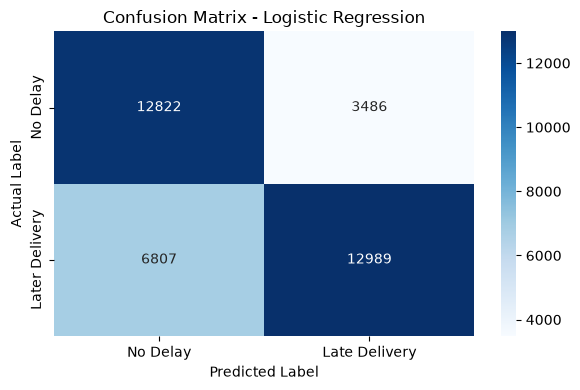

In [69]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Delay","Late Delivery"],
    yticklabels=["No Delay","Later Delivery"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()
plt.savefig(
    GRAPHS_PATH /"confusion_matrix_logistic_regression.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Description: 
The confusion matrix provides a detailed breakdown of the model's predictions. The Logistic Regression model correctly classified 12,822 non-delayed orders and 12,989 late deliveries. It incorrectly predicted 3,486 non-delayed orders as late deliveries and failed to identify 6,807 actual late deliveries. These results indicate that the model is reasonably effective at distinguishing delayed from non-delayed shipments, achieving balanced performance across both classes.

In [70]:
#==================================================
# SAVE LOGISTIC REGRESSION MODEL
#==================================================

with open(

    MODELS_PATH/"logistic_regression.pkl",

    "wb"

) as file:

    pickle.dump(

        log_model,

        file

    )

print(

    "Logistic Regression Saved Successfully."

)

Logistic Regression Saved Successfully.


### ROC Curve

In [71]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [72]:
# Probability values

y_prob_log = log_model.predict_proba(

        X_test_processed

)[:,1]


print(

    "Probability values generated successfully."

)

Probability values generated successfully.


In [73]:
# Calculate ROC values

fpr,tpr,thresholds = roc_curve(

        y_test,
        y_prob_log

)


print(

    "ROC values generated successfully."

)

ROC values generated successfully.


In [74]:
# ROC AUC Score

roc_auc_log = auc(

        fpr,
        tpr

)


print(

    "ROC AUC Score :",
    round(roc_auc_log,4)

)

ROC AUC Score : 0.7827


### ROC Curve Visualization

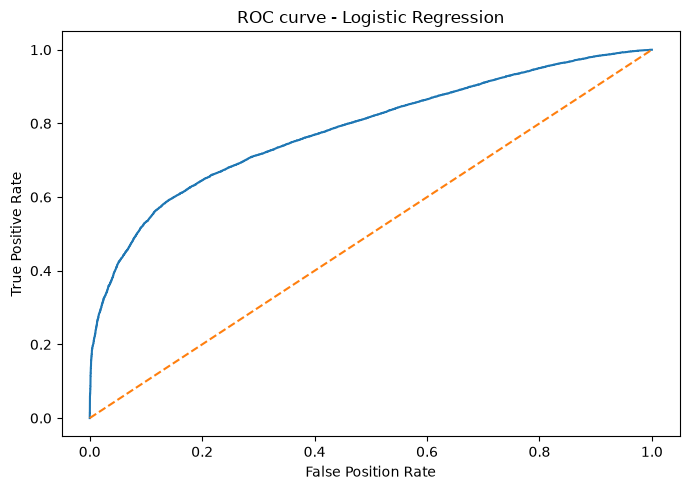

In [75]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_log:.4f}"
)

# random guessing line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Position Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve - Logistic Regression")

plt.tight_layout()

plt.savefig(
    GRAPHS_PATH / "roc_curve_logistic_regression.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Description: 
The ROC curve illustrates the model's ability to distinguish between late and non-delayed deliveries across different probability thresholds. The curve lies substantially above the diagonal reference line, indicating performance significantly better than random guessing. The model achieved an ROC-AUC score of 0.7827, demonstrating good discriminative capability and suggesting that it can effectively rank orders according to their likelihood of being delivered late.

# Random Forest

### Import Random Forest

In [76]:
# ====================================================
# IMPORT RANDOM FOREST
# ====================================================

from sklearn.ensemble import RandomForestClassifier

In [77]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# train the model 

rf_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest Model Successfully Trained.")

Random Forest Model Successfully Trained.


### Predict using Random Forest

In [78]:
# ====================================================
# PREDICTION ON TESTING DATA
# ====================================================

y_pred_rf = rf_model.predict(
    X_test_processed
)

print("Total Predictions :",len(y_pred_rf))

Total Predictions : 36104


### View First Few Predictions

In [79]:
print("\n First 20 Predictions \n")
print(y_pred_rf[:20])


 First 20 Predictions 

[0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 1 1]


### Accuracy Score

In [80]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print(
    "Accuracy Score :",
    round(rf_accuracy,4)
)

Accuracy Score : 0.7919


The Random Forest model achieved an accuracy of 79.19%, indicating that it correctly classified approximately 79 out of every 100 orders as either late or non-late deliveries.

### Classification Report

In [81]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.72      0.89      0.79     16308
           1       0.89      0.71      0.79     19796

    accuracy                           0.79     36104
   macro avg       0.80      0.80      0.79     36104
weighted avg       0.81      0.79      0.79     36104



The model demonstrates balanced predictive performance across both classes. It achieves higher precision (89%) for late delivery predictions, meaning that most orders predicted as late are actually delayed. A recall score of 71% indicates that the model successfully identifies a substantial proportion of late deliveries while maintaining good overall classification performance.

##  RANDOM FOREST CONFUSION MATRIX

In [82]:
rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)
print(rf_cm)

[[14515  1793]
 [ 5722 14074]]


### RANDOM FOREST CONFUSION MATRIX HEATMAP

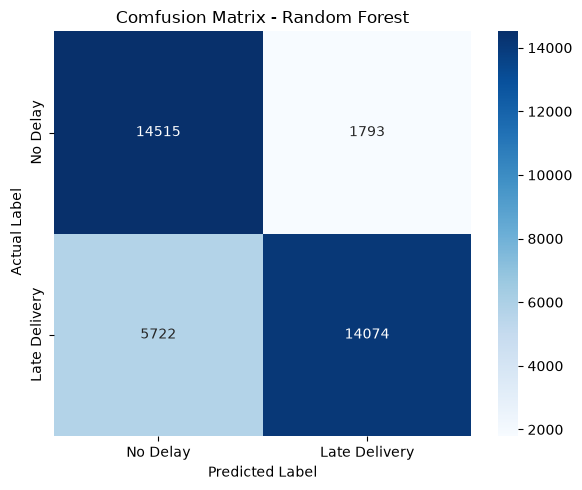

In [83]:
plt.figure(figsize=(6,5))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Delay","Late Delivery"],
    yticklabels=["No Delay","Late Delivery"]
)
plt.xlabel("Predicted Label")
plt.ylabel(" Actual Label")
plt.title("Comfusion Matrix - Random Forest")

plt.tight_layout()

plt.savefig(
    GRAPHS_PATH / "confusion_matrix_random_forest.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Interpretation
The confusion matrix shows that the Random Forest model correctly classified 14,515 non-late deliveries and 14,074 late deliveries. Only 1,793 non-late deliveries were incorrectly predicted as late, while 5,722 late deliveries were missed by the model. Overall, the model demonstrates strong predictive performance with fewer misclassifications and better class separation compared to Logistic Regression.

In [84]:
#==================================================
# SAVE RANDOM FOREST MODEL
#==================================================

with open(

    MODELS_PATH/"random_forest.pkl",

    "wb"

) as file:

    pickle.dump(

        rf_model,

        file

    )

print(

    "Random Forest Saved Successfully."

)

Random Forest Saved Successfully.


### ROC-AUC Score

In [85]:
# probability values
y_prob_rf = rf_model.predict_proba(
    X_test_processed
)[:,1]

# calculate ROC values
fpr,tpr,thresholds = roc_curve(

    y_test,
    y_prob_rf

)

# ROC-AUC score
roc_auc_rf = auc(

    fpr,
    tpr

)

print("ROC-AUC Score :",round(roc_auc_rf,4))

ROC-AUC Score : 0.8893


### ROC Curve

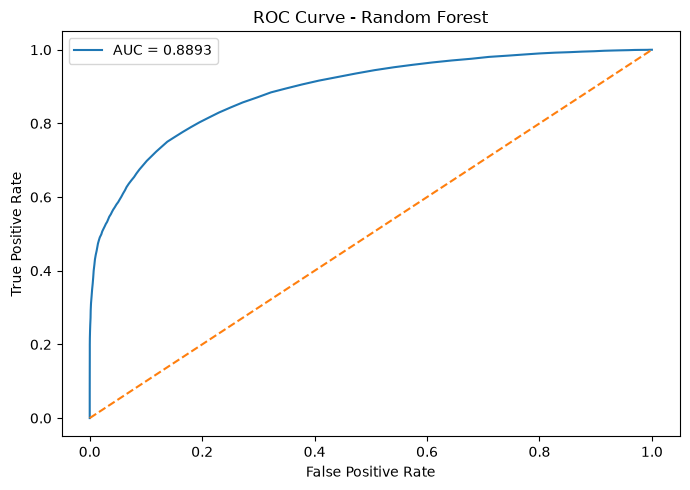

In [86]:
plt.figure(figsize=(7,5))

plt.plot(

    fpr,
    tpr,
    label=f"AUC = {roc_auc_rf:.4f}"

)

plt.plot(

    [0,1],
    [0,1],
    linestyle="--"

)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.tight_layout()

plt.savefig(
    GRAPHS_PATH / "roc_curve_random_forest.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

### Interpretation
The ROC curve demonstrates the Random Forest model's ability to distinguish between late and non-late deliveries across different classification thresholds. The ROC-AUC score of 0.8893 indicates excellent discriminative performance, meaning the model effectively separates both classes and provides reliable predictions for late delivery risk.

# Gradient Boosting Classifier

Gradient Boosting builds multiple weak learners sequentially and improves prediction performance by correcting previous errors. It is used to compare its performance with Logistic Regression and Random Forest for late delivery risk prediction.

In [87]:
from sklearn.ensemble import GradientBoostingClassifier 
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [88]:
# ===================================================
# GRADIENT BOOSTING CLASSIFIER
# ===================================================

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train_processed,
    y_train
)

print("Gradient Boosting Model Trained Successfully.")

Gradient Boosting Model Trained Successfully.


### Prediction

In [89]:
y_pred_gb = gb_model.predict(
    X_test_processed
)

print("Prediction Completed Successfully.")

Prediction Completed Successfully.


### Accuracy Score

In [90]:
gb_accuracy = accuracy_score(
    y_test,
    y_pred_gb
)

print(
    "Gradient Boosting Accuracy :",
    round(gb_accuracy,4)
)

Gradient Boosting Accuracy : 0.6987


The accuracy score represents the overall percentage of correctly
classified orders. Higher values indicate better predictive
performance of the model.

### Classification Report

In [91]:
print(
    classification_report(
        y_test,
        y_pred_gb
    )
)

              precision    recall  f1-score   support

           0       0.62      0.87      0.72     16308
           1       0.84      0.56      0.67     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.70     36104
weighted avg       0.74      0.70      0.69     36104



### Confusion Matrix

The classification report summarizes the model's precision, recall,
F1-score, and overall predictive performance for both classes.

Higher values indicate better classification capability and fewer
prediction errors.

In [92]:
gb_cm = confusion_matrix(
    y_test,
    y_pred_gb
)

print(gb_cm)

[[14201  2107]
 [ 8770 11026]]


### Confusion Matrix Heatmap

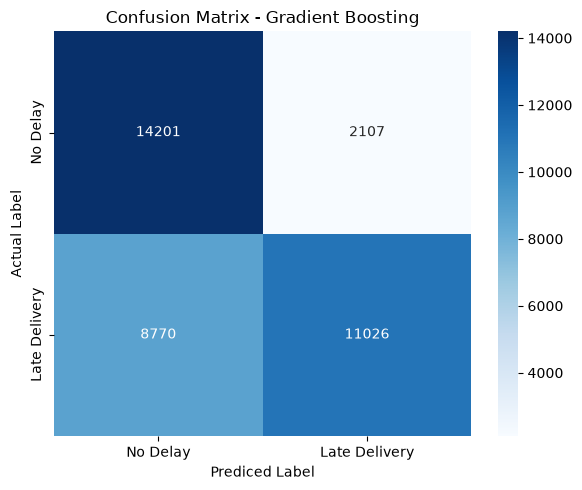

In [93]:
plt.figure(figsize=(6,5))

sns.heatmap(
    gb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Delay", "Late Delivery"],
    yticklabels=["No Delay","Late Delivery"]
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Prediced Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    GRAPHS_PATH / "confusion_matrix_gradient_boosting.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

The confusion matrix shows how accurately the model distinguishes
between delayed and non-delayed orders. Higher values along the
diagonal indicate better predictive performance and fewer
misclassifications.

In [94]:
#==================================================
# SAVE GRADIENT BOOSTING MODEL
#==================================================

with open(

    MODELS_PATH/"gradient_boosting.pkl",

    "wb"

) as file:

    pickle.dump(

        gb_model,

        file

    )

print(

    "Gradient Boosting Saved Successfully."

)

Gradient Boosting Saved Successfully.


### Precision, Recall and F1 Score

In [95]:
gb_report = classification_report(
    y_test,
    y_pred_gb,
    output_dict = True
)


print( 
    "Precision :",
    round(gb_report["1"]["precision"],4)
)
print(
    "Recall :",
    round(gb_report["1"]["recall"],4)
)
print(
    "F1 Score :",
    round( gb_report["1"]["f1-score"],4)
)

Precision : 0.8396
Recall : 0.557
F1 Score : 0.6697


### ROC-AUC Score

In [96]:
# Probability values

y_prob_gb = gb_model.predict_proba(
    X_test_processed
)[:,1]

#Calculate ROC Values

fpr,tpr,thresholds = roc_curve(
    y_test,
    y_prob_gb
)

# ROC_AUC Score

roc_auc_gb = auc(
    fpr,
    tpr
)

print("ROC-AUC Score :",
      round(roc_auc_gb,4)
)

ROC-AUC Score : 0.7492


The ROC-AUC score measures the model's ability to distinguish between
late and non-late deliveries. Higher values indicate stronger class
separation and better predictive performance.

### ROC Curve

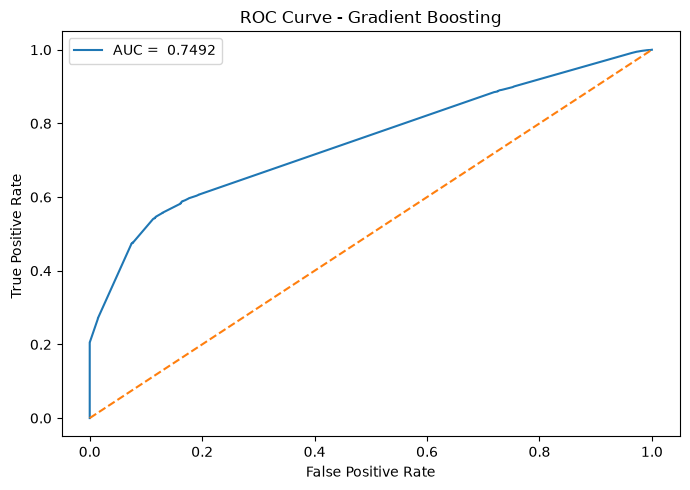

In [97]:
# ===================================================
# ROC CURVE
# ===================================================

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label = f"AUC = {roc_auc_gb : .4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel( "False Positive Rate")

plt.ylabel( "True Positive Rate ")
plt.title("ROC Curve - Gradient Boosting")

plt.legend()
plt.tight_layout()

plt.savefig(
    GRAPHS_PATH / "roc_curve_gradient_boosting.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

The ROC curve illustrates the trade-off between sensitivity and false positive rates across different classification thresholds. A curve closer to the top-left corner indicates better predictive performance.

## Model Comparison Table

In [98]:
comparision_df = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy" :[
        round(log_accuracy,4),
        round(rf_accuracy,4),
        round(gb_accuracy,4)
    ],
    "ROC_AUC":[
        round(roc_auc_log,4),
        round(roc_auc_rf,4),
        round(roc_auc_gb,4)
    ]
})

comparision_df

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.7149,0.7827
1,Random Forest,0.7919,0.8893
2,Gradient Boosting,0.6987,0.7492


In [99]:
#==================================================
# SAVE MODEL COMPARISON
#==================================================

comparision_df.to_csv(

    EXPORTS_PATH/"model_comparison.csv",

    index=False

)

print("Model Comparison Saved Successfully.")

Model Comparison Saved Successfully.


## Best Model Selection

In [100]:
# ====================================================
# BEST MODEL
# ====================================================

model_scores = {
    "Logistic Regression": roc_auc_log,
    "Random Forest":roc_auc_rf,
    "Gradient Boosting" : roc_auc_gb    
}

best_model = max(
    model_scores,
    key=model_scores.get
)
print(
    "Final Selected Model :", 
    best_model
)

Final Selected Model : Random Forest


The three machine learning models were evaluated using Accuracy and ROC-AUC scores. The model demonstrating the strongest predictive performance was selected as the final model for late delivery risk prediction.

The selected model provides reliable predictions that support proactive supply chain planning and operational decision-making.

In [101]:
# ===================================================
# FINAL MODEL ASSIGNMENT
# ===================================================

if best_model == "Random Forest":
    final_model = rf_model  

elif best_model == "Gradient Boosting":
    final_model = gb_model
else: 
    final_model = log_model

print("Final Model :",best_model)

Final Model : Random Forest


## Feature Importance Analysis

In [102]:
feature_importance = final_model.feature_importances_
print("Total Features :",len(feature_importance))

Total Features : 5549


In [103]:
print(type(preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [104]:
feature_names = preprocessor.get_feature_names_out()

In [105]:
print(len(feature_importance))

print(len(feature_names))

5549
5549


In [106]:
importance_df = pd.DataFrame({

    "Feature": feature_names,
    "Importance": feature_importance

})

In [107]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [108]:
importance_df.head(15)

,Feature,Importance
0,num__Days for shipment (scheduled),0.068674
5548,cat__Shipping Mode_Standard Class,0.060365
5545,cat__Shipping Mode_First Class,0.045785
5,num__Latitude,0.029623
6,num__Longitude,0.027669
1,num__Benefit per order,0.025563
14,num__Order Profit Per Order,0.025431
10,num__Order Item Profit Ratio,0.023254
2,num__Sales per customer,0.022434
13,num__Order Item Total,0.022352


Feature importance identifies the most influential variables used by
the model to predict late delivery risk. Higher scores indicate greater
impact on the model's predictions

In [109]:
#==================================================
# SAVE FEATURE IMPORTANCE
#==================================================

importance_df.to_csv(
    EXPORTS_PATH/"feature_importance.csv",
    index=False
)

print("Feature Importtance Saved Successfully.")

Feature Importtance Saved Successfully.


## Top-15 Important Features

In [110]:
top15_features = importance_df.head(15)

top15_features

,Feature,Importance
0,num__Days for shipment (scheduled),0.068674
5548,cat__Shipping Mode_Standard Class,0.060365
5545,cat__Shipping Mode_First Class,0.045785
5,num__Latitude,0.029623
6,num__Longitude,0.027669
1,num__Benefit per order,0.025563
14,num__Order Profit Per Order,0.025431
10,num__Order Item Profit Ratio,0.023254
2,num__Sales per customer,0.022434
13,num__Order Item Total,0.022352


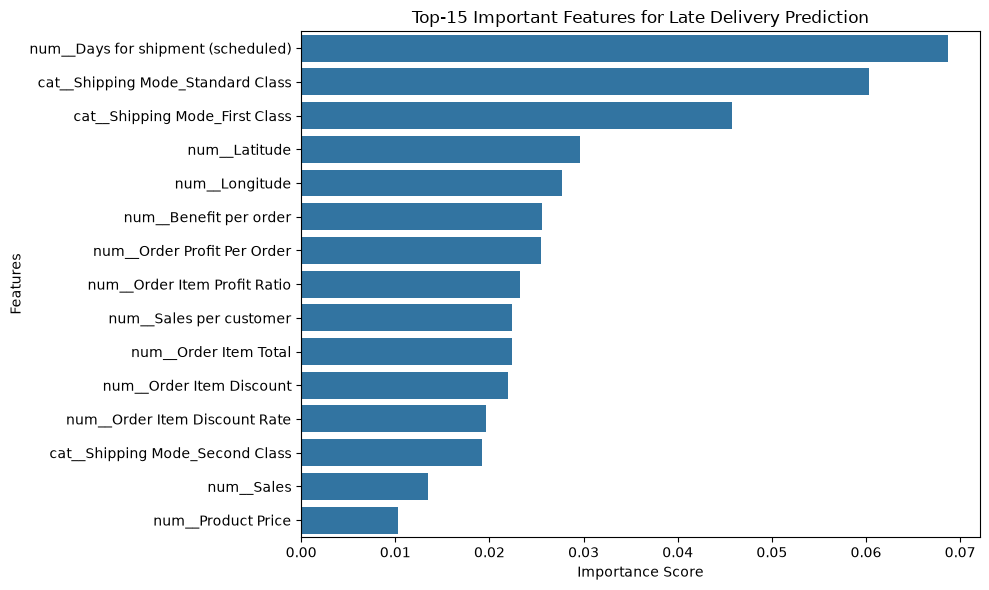

In [111]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top15_features,
    x="Importance",
    y="Feature"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top-15 Important Features for Late Delivery Prediction")

plt.tight_layout()
plt.show()

 The graph highlights the 15 most influential features used by the
Random Forest model. Features with higher importance scores contribute
more significantly to predicting late delivery risk.

In [112]:
#==================================================
# SAVE TOP-15 FEATURES
#==================================================

top15_features.to_csv(
    EXPORTS_PATH/"top15_features.csv",
    index=False
)
print("Top 15 Features Saved Successfully.")

Top 15 Features Saved Successfully.


## Late Delivery Probability Prediction

In [113]:

late_delivery_probability = final_model.predict_proba(
    X_test_processed
)[:,1]

print("Total Probability Values :",
      len(late_delivery_probability))

Total Probability Values : 36104


In [114]:
# First 20 Probability Scores

print("\nFirst 20 Probability Scores\n")

print(
    np.round(
        late_delivery_probability[:20],
        4
    )
)


First 20 Probability Scores

[0.28 0.58 0.11 0.29 0.41 0.33 0.39 0.34 0.97 0.18 0.35 1.   0.37 0.41
 0.67 0.29 0.74 0.94 0.87 1.  ]


### Convert into DataFrame

In [115]:
probability_df = pd.DataFrame({

    "Actual_Label":y_test,
    "Late_Delivery_Probability":
    late_delivery_probability

})

probability_df.head(10)

,Actual_Label,Late_Delivery_Probability
69318,0,0.28
84032,0,0.58
160369,0,0.11
149768,0,0.29
107905,1,0.41
130552,0,0.33
153004,1,0.39
70382,0,0.34
149022,1,0.97
3231,1,0.18


The model assigns a probability score between 0 and 1 indicating
the likelihood of an order being delivered late. Higher values indicate
greater delivery risk.

In [116]:
#==================================================
# SAVE LATE DELIVERY PROBABILITY
#==================================================

probability_df.to_csv(
    EXPORTS_PATH/"late_delivery_probability.csv",
    index=False
)
print("Late Delivery Probability Saved Successfully.")

Late Delivery Probability Saved Successfully.


## Risk Categorization (Low Risk, Medium Risk, High Risk)

In [117]:
# ===================================================
# RISK CATEGORIZATION
# ===================================================

def categorize_risk(probability):

    if probability < 0.30:
        return "Low Risk"

    elif probability < 0.70:
        return "Medium Risk"

    else:
        return "High Risk"


probability_df["Risk_Category"] = (

    probability_df[
        "Late_Delivery_Probability"
    ].apply(categorize_risk)

)

probability_df.head(10)

,Actual_Label,Late_Delivery_Probability,Risk_Category
69318,0,0.28,Low Risk
84032,0,0.58,Medium Risk
160369,0,0.11,Low Risk
149768,0,0.29,Low Risk
107905,1,0.41,Medium Risk
130552,0,0.33,Medium Risk
153004,1,0.39,Medium Risk
70382,0,0.34,Medium Risk
149022,1,0.97,High Risk
3231,1,0.18,Low Risk


### Risk Distribution

In [118]:
# Count Orders in each Risk Category

risk_counts = (

    probability_df["Risk_Category"]
    .value_counts()

)

print(risk_counts)

Risk_Category
Medium Risk    16956
High Risk      11390
Low Risk        7758
Name: count, dtype: int64


In [119]:
#==================================================
# SAVE RISK DISTRIBUTION
#==================================================

risk_counts.to_csv(
    EXPORTS_PATH/"risk_category_distribution.csv"   
)
print("Risk Distribution Saved Successfully.")

Risk Distribution Saved Successfully.


###   Visualization

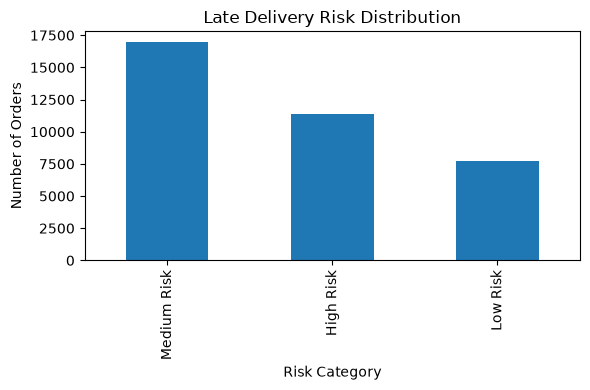

In [120]:
# Risk Category Distribution

plt.figure(figsize=(6,4))

risk_counts.plot(
    kind="bar"
)

plt.title("Late Delivery Risk Distribution")

plt.xlabel( "Risk Category")

plt.ylabel( "Number of Orders")

plt.tight_layout()

plt.show()

Orders are classified into Low, Medium, and High Risk categories
based on their predicted probability of late delivery. High-risk
orders should be prioritized for operational intervention.

## High Risk Orders Analysis

In [121]:
# ===================================================
# HIGH RISK ORDERS ANALYSIS
# ===================================================

high_risk_orders = probability_df[
    probability_df["Risk_Category"] == "High Risk"
]

print(
    "Total High Risk Orders :",
    len(high_risk_orders)
)

Total High Risk Orders : 11390


### View First Few High Risk Orders

In [122]:
high_risk_orders.head(10)

,Actual_Label,Late_Delivery_Probability,Risk_Category
149022,1,0.97,High Risk
1578,1,1.00,High Risk
130545,1,0.74,High Risk
145011,1,0.94,High Risk
29947,1,0.87,High Risk
43259,1,1.00,High Risk
40163,1,0.99,High Risk
175062,1,0.83,High Risk
14405,1,0.89,High Risk
68046,1,0.94,High Risk


In [123]:
#==================================================
# SAVE HIGH RISK ORDERS
#==================================================

high_risk_orders.to_csv(
     EXPORTS_PATH/"high_risk_orders.csv",
     index=False
)

print("High RIsk Orders Saved Successfully.")

High RIsk Orders Saved Successfully.


### Percentage of High Risk Orders

In [124]:
high_risk_percentage = (

    len(high_risk_orders)
    /
    len(probability_df)

) * 100


print(
    "High Risk Orders Percentage :",
    round(high_risk_percentage,2),
    "%"
)

High Risk Orders Percentage : 31.55 %


### Visualization

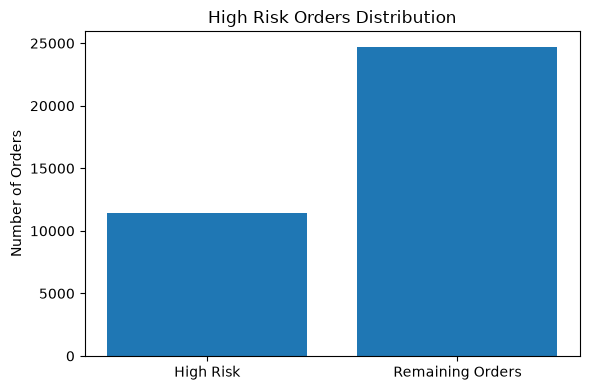

In [125]:
# High Risk vs Remaining Orders

remaining_orders = (

    len(probability_df)
    -
    len(high_risk_orders)

)

values = [

    len(high_risk_orders),
    remaining_orders

]

labels = [

    "High Risk",
    "Remaining Orders"

]


plt.figure(figsize=(6,4))

plt.bar(
    labels,
    values
)

plt.title("High Risk Orders Distribution")

plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

High-risk orders have the greatest likelihood of being delayed and
should be prioritized for timely intervention and operational planning.

## KPI-1 : Late Delivery Probability

In [126]:
min_probability = probability_df["Late_Delivery_Probability"].min()
max_probability = probability_df["Late_Delivery_Probability"].max()
avg_probability = probability_df["Late_Delivery_Probability"].mean()

print("Minimum Probability :",round(min_probability,4))
print("Maximum Probability :",round(max_probability,4))
print("Average Probability :",round(avg_probability,4))

Minimum Probability : 0.01
Maximum Probability : 1.0
Average Probability : 0.5394


## KPI-2 : Risk Category Distribution

In [127]:

risk_distribution = (
    probability_df["Risk_Category"]
    .value_counts()
)

print(risk_distribution)

Risk_Category
Medium Risk    16956
High Risk      11390
Low Risk        7758
Name: count, dtype: int64


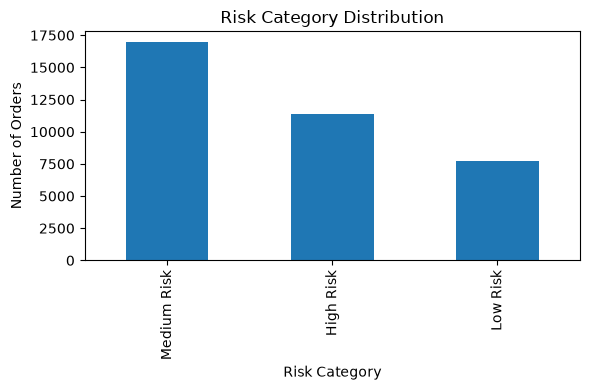

In [128]:
plt.figure(figsize=(6,4))

risk_distribution.plot(
    kind="bar"
)

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

## KPI-3 : Key Risk Drivers

In [129]:

top5_features = (
    importance_df
    .head(5)
)

top5_features

,Feature,Importance
0,num__Days for shipment (scheduled),0.068674
5548,cat__Shipping Mode_Standard Class,0.060365
5545,cat__Shipping Mode_First Class,0.045785
5,num__Latitude,0.029623
6,num__Longitude,0.027669


In [130]:

top5_features = (
    importance_df
    .head(5)
)

top5_features

,Feature,Importance
0,num__Days for shipment (scheduled),0.068674
5548,cat__Shipping Mode_Standard Class,0.060365
5545,cat__Shipping Mode_First Class,0.045785
5,num__Latitude,0.029623
6,num__Longitude,0.027669


## KPI-4 : High Risk Order List

In [131]:
print(
    "Total High Risk Orders :",
    len(high_risk_orders)
)

high_risk_orders.head(10)

Total High Risk Orders : 11390


,Actual_Label,Late_Delivery_Probability,Risk_Category
149022,1,0.97,High Risk
1578,1,1.00,High Risk
130545,1,0.74,High Risk
145011,1,0.94,High Risk
29947,1,0.87,High Risk
43259,1,1.00,High Risk
40163,1,0.99,High Risk
175062,1,0.83,High Risk
14405,1,0.89,High Risk
68046,1,0.94,High Risk


## KPI-5 : High Risk Orders Percentage

In [132]:
high_risk_percentage = (

    len(high_risk_orders)
    /
    len(probability_df)

)*100

print(
    "High Risk Orders Percentage :",
    round(high_risk_percentage,2),
    "%"
)

High Risk Orders Percentage : 31.55 %


## KPI-6 : Total Orders Analysed

In [133]:

print(
    "Total Orders Analysed :",
    len(probability_df)
)

Total Orders Analysed : 36104


## KPI-7 : Average Late Delivery Probability

In [134]:

average_probability = (
    probability_df[
        "Late_Delivery_Probability"
    ].mean()
)

print(
    "Average Late Delivery Probability :",
    round(average_probability,4)
)

Average Late Delivery Probability : 0.5394


In [135]:
#==================================================
# SAVE KPI SUMMARY
#==================================================

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "High Risk Orders",
        "High Risk Percentage",
        "Average Probability"
    ],
    "Value":[
        len(probability_df),
        len(high_risk_orders),
        round(high_risk_percentage,2),
        round(avg_probability,4)
    ]
})

kpi_summary.to_csv(
    EXPORTS_PATH/"kpi_summary.csv",
    index=False
)
print("KPI Summary Saved Successfully.")

KPI Summary Saved Successfully.


# BUSINESS RECOMMENDATIONS

### 1. Prioritize High-Risk Orders:
Orders classified as High Risk should be monitored proactively to
reduce late delivery occurrences.

### 2. Optimize Shipping Methods:
Shipping modes identified as important predictors should be reviewed
to improve delivery performance.

### 3. Improve Delivery Scheduling:
Scheduled shipment duration significantly influences delay risk.
Improving shipment planning can minimize delays.

### 4. Monitor High-Risk Percentages:
Operational teams should regularly monitor the percentage of
high-risk orders for timely intervention.

### 5. Focus on Key Risk Drivers:
Business decisions should consider the most influential factors
identified by the Random Forest model.

### 6. Implement Risk-Based Prioritization:
Orders with higher late delivery probabilities should receive
higher operational priority.

### 7. Utilize Predictive Analytics:
The developed model can assist supply chain teams in anticipating
delivery risks and improving customer satisfaction.

## Business Recommendations Interpretation

The recommendations are derived from the model's predictive insights.
Prioritizing high-risk orders, optimizing shipment planning, and
monitoring key risk factors can improve operational efficiency and
reduce late delivery risks across the supply chain.

## Save the Final Model


In [136]:
import pickle

with open(MODELS_PATH/"random_forest_model.pkl","wb") as file:
   pickle.dump(
      final_model,
      file
   )

   print("Random Forest Model Saved Successfully.")

Random Forest Model Saved Successfully.


## Load the Saved Model

In [137]:
with open(MODELS_PATH/"random_forest_model.pkl","rb") as file:

    saved_model = pickle.load(file)


print(type(saved_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [138]:
#==================================================
# SAVE PREPROCESSOR
#==================================================

with open(

    MODELS_PATH/"preprocessor.pkl",

    "wb"

) as file:


    pickle.dump(

        preprocessor,

        file

    )


print("Preprocessor Saved Successfully.")

Preprocessor Saved Successfully.


# FINAL MODEL SUMMARY

### **• Logistic Regression was used as the baseline model.**

### **• Random Forest achieved the best predictive performance and was selected as the final model.**

### **• The model successfully predicts late delivery risk using shipment, sales, geographical, and shipping-related features.**

### **• Orders are classified as either Late Delivery Risk or Non-Late Delivery Risk based on the model's predictions.**

### **• Feature importance analysis identified the most influential variables contributing to late delivery predictions.**

### **• The developed model can support proactive supply chain planning and timely operational decision-making.**

## Exports

# **FINAL CONCLUSION**

### **This project successfully developed a machine learning-based solution for predicting late delivery risks in global supply chain operations.**
### **To ensure reliable predictions, data leakage variables were excluded from model training. The Random Forest model demonstrated strong predictive performance and was selected as the final model after evaluating multiple machine learning approaches.**

### **The model enables early identification of potentially delayed orders and provides valuable business insights through probability-based risk assessment and feature importance analysis.**

### **By supporting proactive operational planning and risk-based decision-making, this solution can contribute to improved delivery performance, enhanced customer satisfaction, and more efficient supply chain management.**

# **Project Limitations**


### **• The model relies on historical shipment and order data and may require periodic retraining to maintain performance.**

### **• External factors such as weather conditions, traffic disruptions, and transportation constraints are not included in the dataset.**

### **• Prediction quality depends on the completeness and accuracy of the available data.**

### **• The model provides risk predictions but does not determine the exact cause of individual delivery delays.**

### **• Business patterns may evolve over time, affecting model generalization if new data characteristics emerge.**













# **Future Scope**


### **• Integrate real-time shipment data for continuous late delivery risk monitoring.**

### **• Develop an interactive Streamlit dashboard for operational decision-making.**

### **• Incorporate additional business variables such as weather conditions, transportation delays, and warehouse-level information.**

### **• Explore advanced machine learning techniques and model optimization strategies to improve predictive performance.**

### **• Extend the system to support real-time supply chain risk management, delivery optimization, and automated alert generation for high-risk orders.**

# Report Generation

This section automatically generates and saves the final project reports containing the model performance, KPIs, business insights, and project conclusions.

In [139]:
#==================================================
# IMPORT LIBRARIES
#==================================================

import os
from datetime import datetime

In [140]:
#==================================================
# CREATE REPORTS FOLDER
#==================================================

os.makedirs("reports",exist_ok=True)

print("Reports Folder Ready.")

Reports Folder Ready.


In [141]:
#==================================================
# EXECUTIVE SUMMARY
#==================================================

summary = f"""

PROJECT TITLE
--------------
Machine Learning-based Late Delivery Risk Prediction
in Global Supply Chain Operations


BEST MODEL
-----------
{best_model}


MODEL PERFORMANCE
-----------------
Random Forest Accuracy : {round(rf_accuracy,4)}

Random Forest ROC-AUC : {round(roc_auc_rf,4)}


HIGH RISK ORDERS
----------------

Total High Risk Orders :
{len(high_risk_orders)}

High Risk Percentage :
{round(high_risk_percentage,2)} %


TOP RISK DRIVER
----------------

{importance_df.iloc[0,0]}


"""

with open(
    "reports/Executive_Summary.txt",
    "w",
    encoding="utf-8"

) as file:

    file.write(summary)

print("Executive Summary Saved Successfully.")

Executive Summary Saved Successfully.


In [142]:
#==================================================
# PROJECT RESULTS
#==================================================

results = f"""

MODEL RESULTS
--------------

Logistic Regression Accuracy :
{round(log_accuracy,4)}

Random Forest Accuracy :
{round(rf_accuracy,4)}


ROC-AUC SCORES
---------------

Logistic Regression :
{round(roc_auc_log,4)}

Random Forest :
{round(roc_auc_rf,4)}


KPIs
------

Late Delivery Probability

Risk Category

Key Risk Drivers

High Risk Order List


BUSINESS RECOMMENDATIONS
------------------------

1. Prioritize High Risk Orders.

2. Monitor Shipping Modes.

3. Improve delivery planning.

4. Focus on major risk drivers.


FINAL CONCLUSION
----------------

Random Forest was selected as the final model for predicting
late delivery risk due to its superior predictive performance.

"""

with open(

        "reports/Project_Results.txt",
        "w",
        encoding="utf-8"

) as file:

        file.write(results)

print("Project Results Saved Successfully.")

Project Results Saved Successfully.


In [149]:
metrics_df = pd.DataFrame({

"Model":[
"Random Forest",
"Logistic Regression",
"Gradient Boosting"
],

"Accuracy":[
rf_accuracy,
log_accuracy,
gb_accuracy
],

"ROC AUC":[
roc_auc_rf,
roc_auc_log,
roc_auc_gb
]

})

In [154]:
metrics_df.to_csv(

    EXPORTS_PATH/"model_metrics.csv",

    index=False
 
)
print("Metric Model Save Successfully.")

Metric Model Save Successfully.
